У цьому домашньому завданні ми будемо працювати з набором даних Tips. Нижче інформація про нього.

**Про датасет:**

Tips - це датасет, який містить інформацію про рахунки та чайові в ресторані.

**Колонки датасету:**
- `total_bill` - загальна сума рахунку (долари)
- `tip` - розмір чайових (долари)
- `sex` - стать відвідувача (Male/Female)
- `smoker` - чи курить (Yes/No)
- `day` - день тижня (Thur/Fri/Sat/Sun)
- `time` - час відвідування (Lunch/Dinner)
- `size` - розмір групи (кількість людей)

**Джерело:** Оригінальні дані зібрані в одному з американських ресторанів у 1990-х роках. Скачати і переглянути набір даних можна тут: https://www.kaggle.com/datasets/sakshisatre/tips-dataset

А також ми вже вивантажили файл з даними і завантажили вам у Матеріали до цього модуля.




**1. Гістограма розподілу рахунків**
Завантажте датасет Tips (Чайові) з файла у матеріалах `tips.csv`.
Створіть гістограму для колонки `total_bill` з 20 bins.
Опціонально можна додати підписи осей ОХ, ОУ, а також назву графіку.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [4]:
df = pd.read_csv('tips.csv')

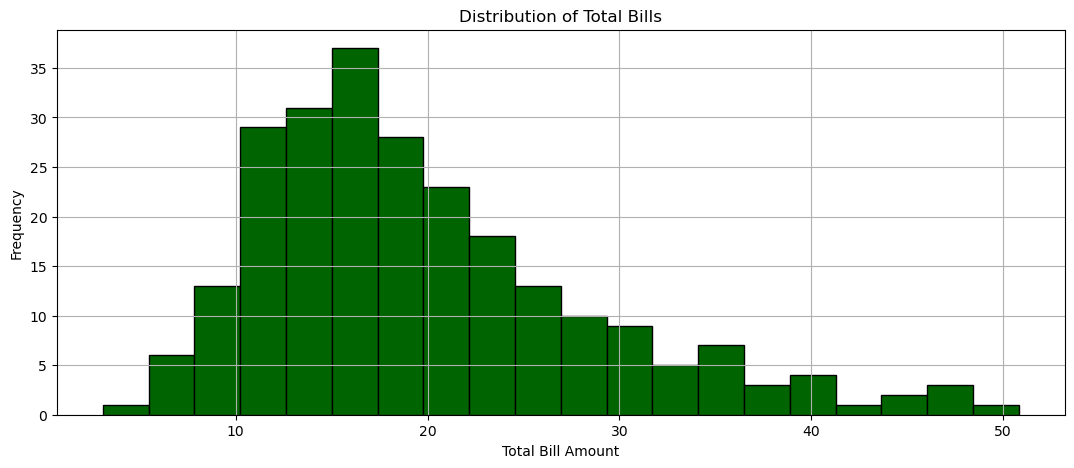

In [14]:
df['total_bill'].hist(bins=20, color='darkgreen', edgecolor='black', figsize=(13,5))
plt.title("Distribution of Total Bills")
plt.xlabel("Total Bill Amount")
plt.ylabel("Frequency");

---

**2. Box plot чайових за днями тижня**

Створіть box plot, який показує розподіл чайових (`tip`) за днями тижня (`day`).
В який день навище медіанне (середнє) значення чайоивх? Зелена горизонтальна лінія всередині кожного box-plot.


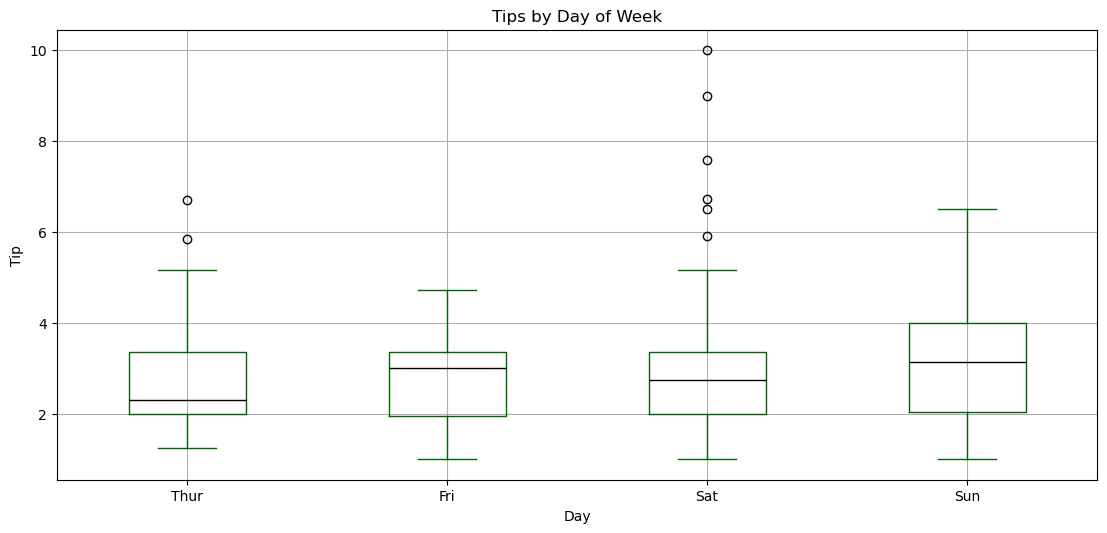

In [46]:
df['day'] = pd.Categorical(
    df['day'],
    categories=['Thur', 'Fri', 'Sat', 'Sun'],
    ordered=True
)

df.boxplot(column='tip', by='day', figsize=(13,5),  color=dict(boxes='#006400', whiskers='#006400', medians='black', caps='#006400'))
plt.title('Tips by Day of Week')
plt.suptitle('')
plt.xlabel('Day')
plt.ylabel('Tip');

The highest median tip value is on Sunday

---

**3. Scatter plot: рахунок vs чайові**

Створіть діаграму розсіювання для `total_bill` та `tip`.

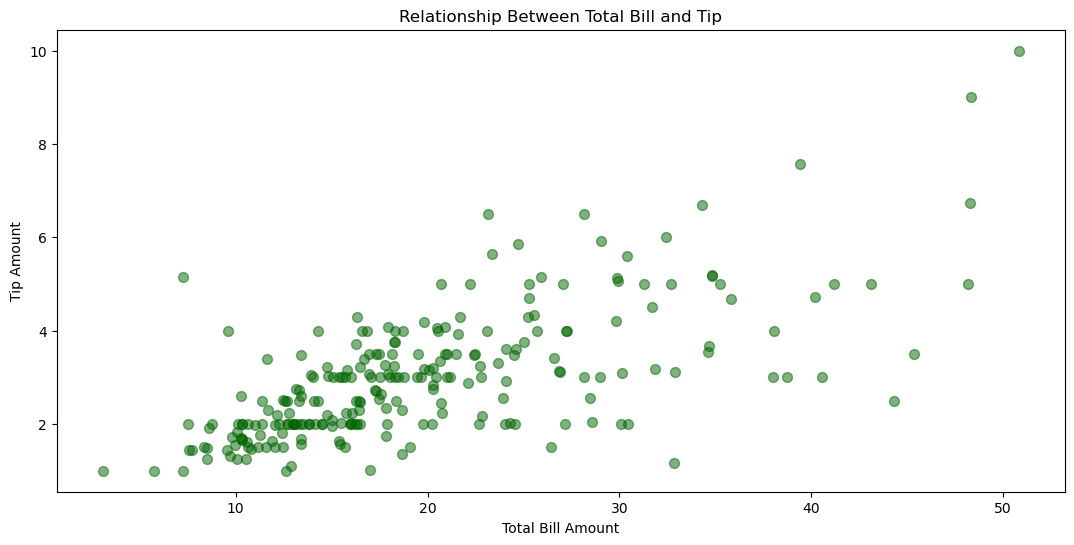

In [42]:
df.plot.scatter(x='total_bill', y='tip', color='darkgreen', alpha=0.5, s=50, figsize=(13,6))
plt.title('Relationship Between Total Bill and Tip')
plt.xlabel('Total Bill Amount')
plt.ylabel('Tip Amount');

---

**4. Bar chart: середній рахунок за часом**

Створіть стовпчасту діаграму середнього рахунку за часом дня (`time`).

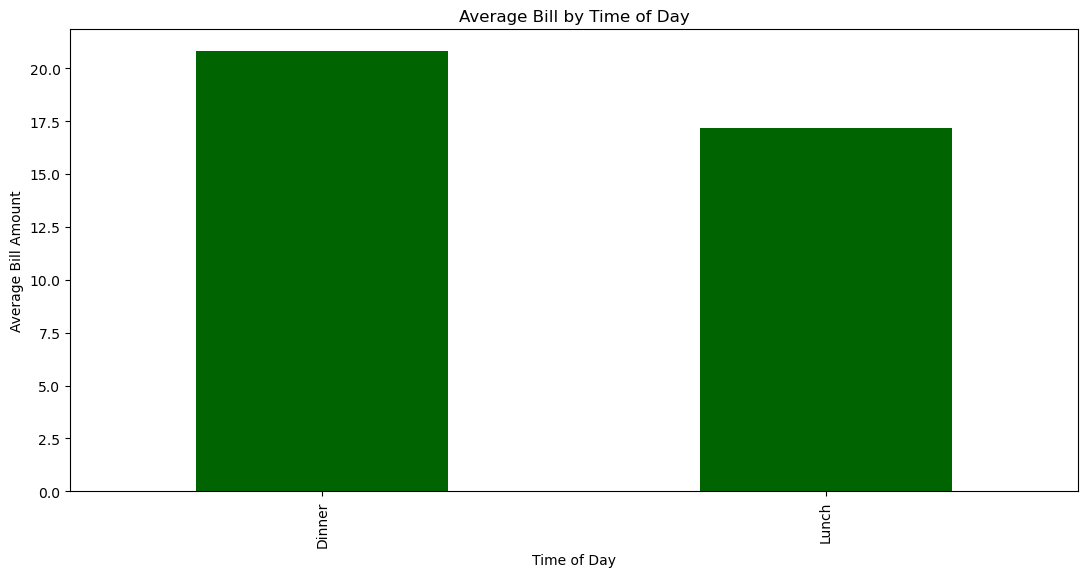

In [45]:
df.groupby('time')['total_bill'].mean().plot.bar(color='darkgreen', figsize=(13,6))
plt.title('Average Bill by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Bill Amount');

---

**5. Інтерактивна діаграма розсіювання**

Створіть з допомогою бібліотек Plotly інтерактивний scatter plot для `total_bill` vs `tip` з кольором за статтю (`sex`).


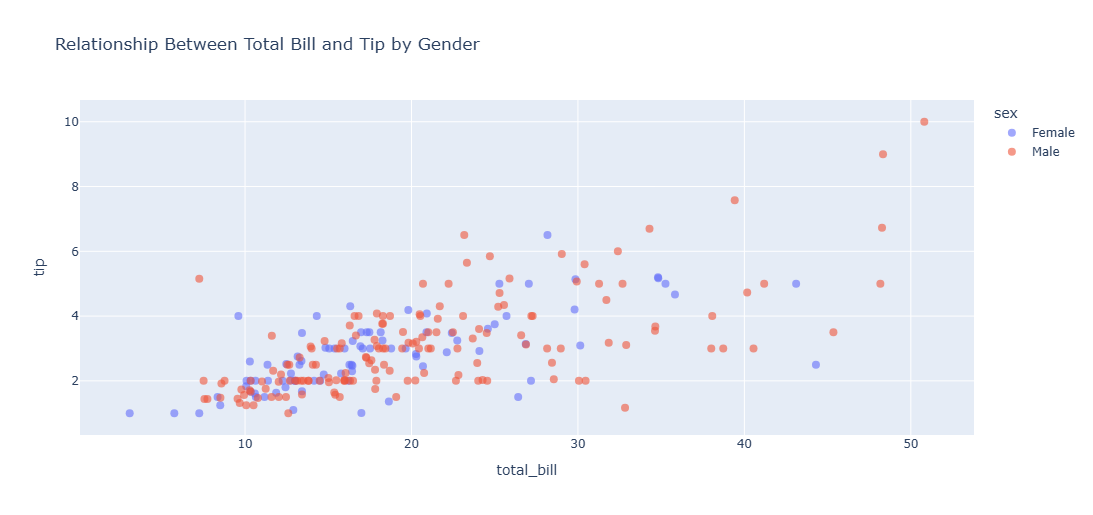

In [55]:
fig = px.scatter(
    df,
    x='total_bill',
    y='tip',
    color='sex',
    title='Relationship Between Total Bill and Tip by Gender',
    width=1100,
    height=500,
    opacity=0.6)

fig.update_traces(marker=dict(size=8))

fig.show()

---

**6. Інтерактивний box plot: чайові за днями та статтю**

Створіть інтерактивний box plot для чайових за днями тижня з розбивкою за кольором по статі.

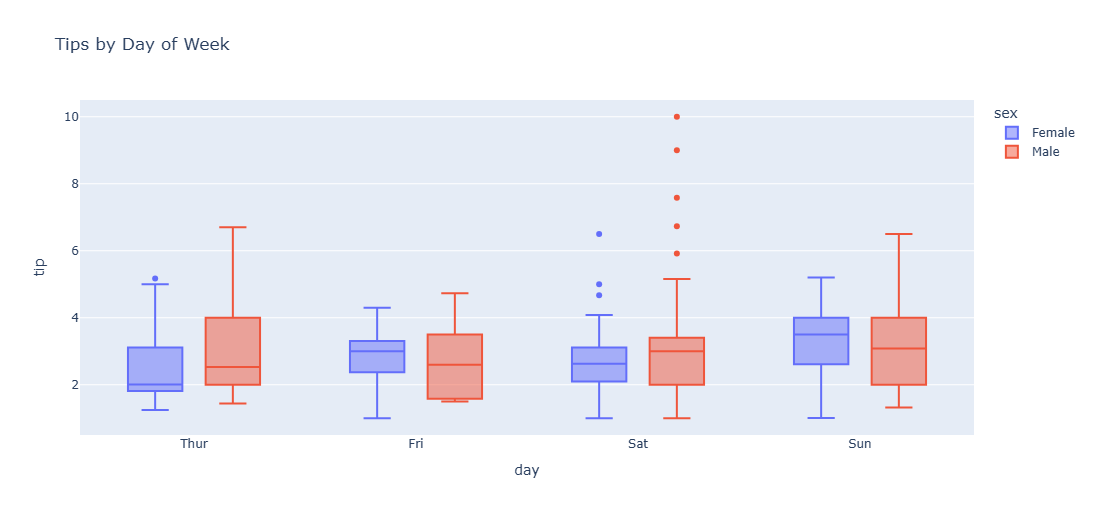

In [56]:
px.box(df, 
       x='day', 
       y='tip', 
       color='sex',
       title='Tips by Day of Week', 
       category_orders={'day': ['Thur', 'Fri', 'Sat', 'Sun']}, 
       width=1100, 
       height=500)
